# Yin-Yang Decision Boundaries 

> We use our training data to fit a DMD model by using time embeddings and a single trajectory.

#### Imports

In [ ]:
from ast import literal_eval

import einops
import matplotlib.pyplot as plt
import matrepr
import numpy.random as rnd
import pykoopman as pk
from matrepr import mprint
from pydmd import DMD, FbDMD
from safetensors.torch import load_file, load_model, save_model
from torch.nn import functional as F
from torchvision import datasets, transforms
from learningdynamics.dmd_data import reshape_append_time
from learningdynamics.models import MLP, init_weights
from learningdynamics.utils import (
    compute_model_accuracy,
    safetensors_metadata_parser,
)
from learningdynamics.visualization import plot_decision_boundary_movie, plot_decision_boundary_koopman
from learningdynamics.datasets import YinYangBinaryDataset
from learningdynamics.koopman_inference import inference_with_koopman
from matplotlib.animation import FuncAnimation
import seaborn as sns
import torch.nn as nn
from torcheval.metrics import MulticlassAccuracy
from torch.utils.data import DataLoader, Subset
import numpy as np
import warnings
from learningdynamics.utils import getActivation
import torch
import math

In [ ]:
# | hide
np.random.seed(42)  # for reproducibility
%matplotlib inline

In [ ]:
# Load YinYang dataset
NUM_SAMPLES = 1000
dataset = YinYangBinaryDataset(num_samples=NUM_SAMPLES, negative_label=False, seed=123)

# Load model
file_path = f"../saved_weights/yinyang_model.safetensors"
metadata = safetensors_metadata_parser(file_path=file_path)
model = MLP(
    config=literal_eval(metadata["config"]),
    nonlinearity=metadata["nonlinearity"],
)
_ = load_model(model, file_path, device="cuda:0")

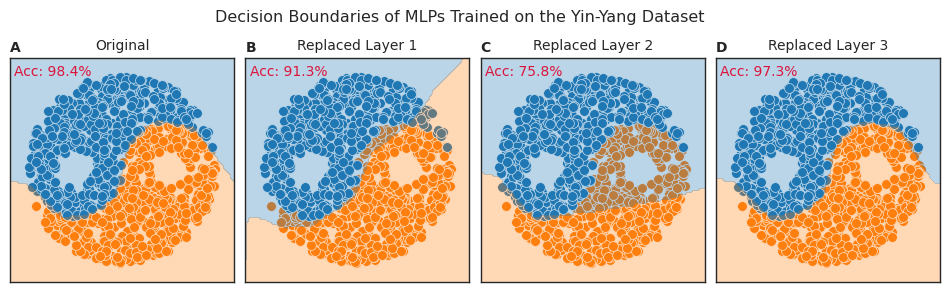

In [ ]:
LAYERS = [1,3,5]
keys = ["A", "B", "C", "D"]
FONTSIZE = 10

# Set the overall theme without a grid
sns.set_context("paper")
sns.set_style("white")

# Plot
fig, axs = plt.subplots(1,len(LAYERS)+1, figsize=(3*(len(LAYERS)+1),3), sharex=True, sharey=True)
if type(axs) is not np.ndarray:
    axs = np.array(axs)

accuracy=compute_model_accuracy(model.to('cpu'), dataset)
ani = plot_decision_boundary_movie(
            model,
            [model.state_dict()],
            dataset.features,
            dataset.labels.squeeze(),
            labels=[0, 1],
            ax=axs[0],
    )
axs[0].set_title(f"Original", fontsize=FONTSIZE)
axs[0].text(0.02, 0.97, f"Acc: {accuracy.item() * 100:.1f}%", transform=axs[0].transAxes, ha='left', va='top', fontsize=FONTSIZE, color='crimson')
axs[0].text(0.00, 1.03, keys[0], transform=axs[0].transAxes, fontsize=FONTSIZE, weight='bold')

# Layers
for i, layer_start in enumerate(LAYERS):

    file_path = f"../saved_weights/yinyang_start{layer_start}_states.safetensors"

    # Load trajectories
    metadata = safetensors_metadata_parser(file_path=file_path)
    NUM_TRAJECTORIES = literal_eval(metadata["num_trajectories"])
    NUM_STATES = literal_eval(metadata["num_states"])
    NUM_ITERATIONS = literal_eval(metadata["num_iterations"])
    NUM_STATES_OF_INTEREST = literal_eval(metadata["num_usable_states"])
    data = load_file(file_path)

    # Edit values
    NUM_TRAJECTORIES = 1_000
    NUM_STATES = NUM_STATES
    supplements =  0
    NUM_DELAYS = (NUM_ITERATIONS-2) + NUM_ITERATIONS*supplements

    # Load data
    t = np.arange(0, NUM_ITERATIONS, 1)
    train_states = reshape_append_time(
        data["train_states"][:NUM_ITERATIONS, :NUM_TRAJECTORIES, :NUM_STATES]
    )
    observables = pk.observables.TimeDelay(delay=1, n_delays=NUM_DELAYS)

    # DMD
    # regressor = pk.regression.EDMD()
    regressor = pk.regression.EDMD(svd_rank=85)
    dmd_model = pk.Koopman(observables=observables, regressor=regressor)
    dmd_model.fit(train_states.numpy().T)

    # Load scaled model
    file_path = f"../saved_weights/yinyang_start{layer_start}_scaled_model.safetensors"
    metadata = safetensors_metadata_parser(file_path=file_path)
    scaled_model = MLP(
        config=literal_eval(metadata["config"]),
        nonlinearity=metadata["nonlinearity"],
    )
    _ = load_model(scaled_model, file_path, device="cuda:0")

    _, accuracy = inference_with_koopman(
        nn_model=scaled_model,
        dmd_model=dmd_model,
        test_set=dataset,
        layer_start=literal_eval(metadata["layer_start"]),
        num_iterations=NUM_ITERATIONS,
        num_delays=NUM_DELAYS,
        num_usable_states=NUM_STATES_OF_INTEREST,
        test_size=NUM_SAMPLES,
    )

    ani = plot_decision_boundary_koopman(
                model=scaled_model,
                state_dicts=[scaled_model.state_dict()],
                X=dataset.features,
                y=dataset.labels.squeeze(),
                dmd_model=dmd_model,
                layer_start=literal_eval(metadata["layer_start"]),
                num_iterations=NUM_ITERATIONS,
                num_delays=NUM_DELAYS,
                num_usable_states=NUM_STATES_OF_INTEREST,
                ax=axs[i+1],
                labels=[0, 1],
        )
    axs[i+1].set_title(f"Koopman Hybrid \n (Hidden Layer {(layer_start+1)//2})", fontsize=FONTSIZE)
    axs[i+1].set_title(f"Replaced Layer {(layer_start+1)//2}", fontsize=FONTSIZE)
    axs[i+1].text(0.02, 0.97, f"Acc: {accuracy.item() * 100:.1f}%", transform=axs[i+1].transAxes, ha='left', va='top', fontsize=FONTSIZE, color='crimson')
    axs[i+1].text(0.00, 1.03, keys[i+1], transform=axs[i+1].transAxes, fontsize=FONTSIZE, weight='bold')

plt.suptitle(f"Decision Boundaries of MLPs Trained on the Yin-Yang Dataset", y=1.03)
plt.subplots_adjust(wspace=0.05, hspace=0.05)  # Modify these values to control spacing
plt.xticks([])
plt.yticks([])

plt.savefig('yinyang_boundaries.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()